In [1]:
# First cell (once)
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from CustomFunctions import LPFeasibleRegionPlotter
import pulp as PLP
from CustomFunctions import print_solution

# Spm. 1)

Th

Jeg bruger en hjemmelavet funktion der tegner det brugbare løsningsområde
for LP problemet

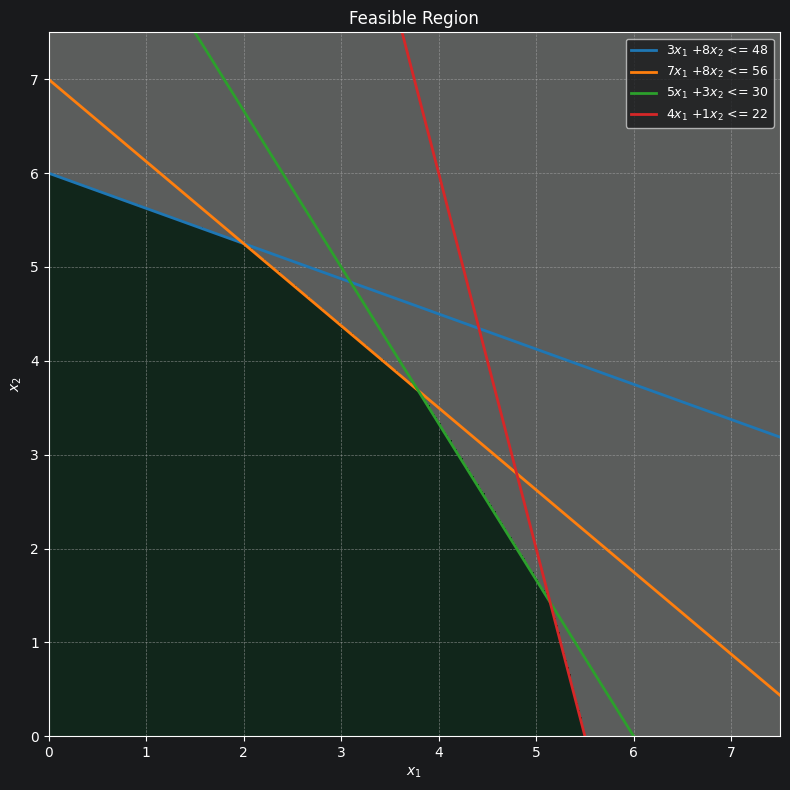

In [2]:
# Plot
coeffcient_matrix = np.array([[3,8], [7,8], [5,3], [4,1]])
ineq_types = np.array(['<=', '<=', '<=', '<='])
rhs = np.array([48, 56, 30, 22])

region = LPFeasibleRegionPlotter(
    coeffcient_matrix, rhs, ineq_types,
    x1_bounds=(0,7.5), x2_bounds=(0,7.5)
)

fig, ax = region.plot()
plt.show()   # first render

Jeg markerer de brugbare integral løsninger med rødt.

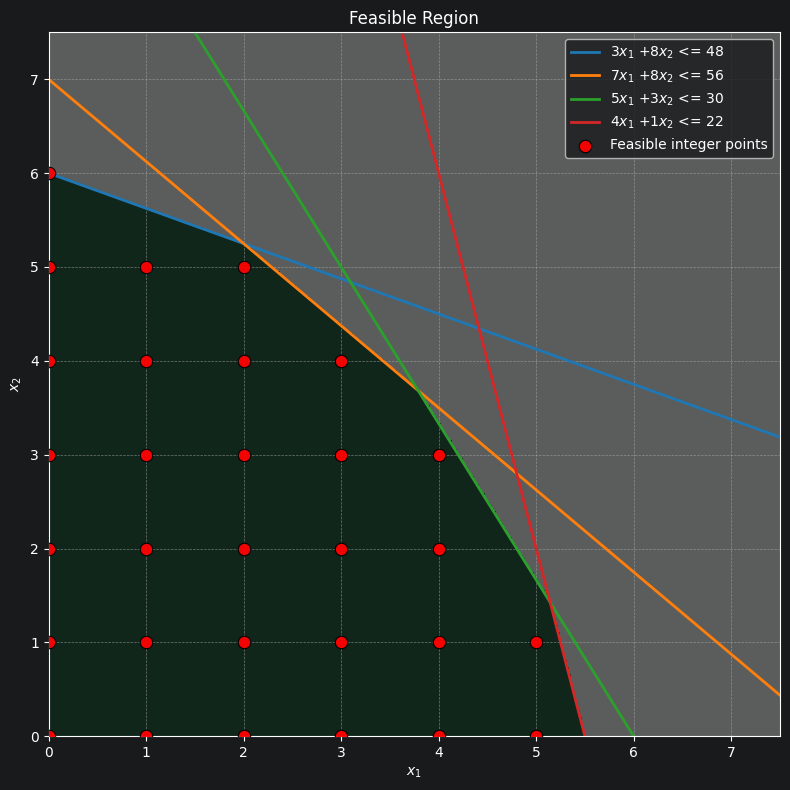

In [3]:
# 2) Add scatter points on top
x_pts = list(range(6)) + list(range(6)) + list(range(5)) + list(range(5)) + list(range(4)) + list(range(3)) + list(range(1))
y_pts = [0]*6 +[1]*6 + [2]*5 + [3]*5 + [4]*4 + [5]*3 + [6]
fig,ax = region.plot()
ax.scatter(
    x_pts,
    y_pts,
    s=80,                 # marker size
    c="red",              # color
    marker="o",           # marker style
    edgecolors="black",
    linewidths=0.8,
    alpha=0.95,
    zorder=10,            # higher than region/lines so it's on top
    label="Feasible integer points"
)
plt.legend()
plt.show()


# Spm. 2)
Branch and Bound metoden kan i sin helhed forklares ved at man relakserer
betingelser på sit optimerings problem. Denne relaksation giver imidlertid
grobund for at udvidde det brugbare løsningsdomæne. Vi kan bruge dette
udvidede løsningsdomæne til at beregne, i dette tilfælde, lower bounds til
vores løsning, da vi ved at løsningsmængden til ILP problemet er et
subset at løsningsmængden for LP problemet.

Når vi finder disse lower bounds, bruger vi så heltalsbetingelsen på en
beslutningsvariabel, til at indskrænke løsningsmængden. Branching aspektet
fremkommer altså ved at vælge en variabel der ikke opfylder begrænsningerne,
 og pålægge den yderligere betingelser.
    Bounding er at finde nedre grænser for objektfunktionen i
    minimeringsproblemer (øvre grænser i maksimeringsproblemer).
 Indskrænkningen i
 ILP-frameworket er at begrænse løsninger til at
 ligger på eller over det nærmeste øvre heltal, eller på eller under det
 nærmeste nedre heltal:
$$x \geq \lceil x^* \rceil $$
og
$$x \leq \lfloor x^* \rfloor $$
hvor $x^*$ betegner den optimale løsning for LP problemet på den branchede
variabel.

Fortsættes denne brancing og bounding iterativt, vil man at til sidste at nå
 en
løsning der er optimal for ILP problemet, ved at forkaste løsningstier der
ikke fører til en forbedring i det lower bound, såfremt der findes en
optimal løsning.

Jeg bruger metodikken Branching med LP bound til ILP, slide 19, fra Kap8\_
Heltalsprogrammering, uge 11. Jeg omdanner problemet til et minimerings
problem da slidesne antager minimering. Vi har generelt at maximum af $f
(x)$
kan findes som minimum
af $g
(x) = -f(x)$

In [4]:
def define_model():
    model = PLP.LpProblem(name="ILP2021", sense=PLP.LpMinimize)

    x_range = range(2)
    x1 = PLP.LpVariable("x1", cat=PLP.LpContinuous, lowBound=0)
    x2 = PLP.LpVariable("x2", cat=PLP.LpContinuous, lowBound=0)

    # Maximization Objective forumalted as a minimization problem
    model += -(8*x1 + 7*x2), "Objective"

    # Constraints
    n,m = coeffcient_matrix.shape
    for i in range(n):
        model += PLP.lpSum(coeffcient_matrix[i,j]*[x1,x2][j]
        for j in range(m)) <= rhs[i], f"Constraint_{i+1}"
    return model, x1, x2

model, x1, x2 = define_model()
# Solve model and print the solution.
print_solution(model, condition = lambda x: abs(x.varValue) >= 0.1)


Status: Optimal
x1 = 3.7894737
x2 = 3.6842105
Obj. =  -56.1052631


Jeg brancher nu på $x_1$ og tilføjer begrænsningerne fra det løste LP
problem i to subproblemer

$$x_1 \leq \lfloor 3.78 \rfloor = 3$$
og
$$x_1 \geq \lceil 3.78 \rceil = 4$$

## Delproblem 1

In [5]:
model += x1 <= 3, "Branch_x1_leq_3"
print_solution(model, condition = lambda x: abs(x.varValue) >= 0.1)


Status: Optimal
x1 = 3.0
x2 = 4.375
Obj. =  -54.625


## Delproblem 2

In [6]:
model, x1, x2 = define_model()  # Reset model to original
model += x1 >= 4, "Branch_x1_geq_4"
print_solution(model, condition = lambda x: abs(x.varValue) >= 0.1)


Status: Optimal
x1 = 4.0
x2 = 3.3333333
Obj. =  -55.333333100000004


Det ses at delproblem 2 har den største objektværdi, og er heltallig i
$x_1$, da vælger vi at branche her på denne løsning, da vi har et
maksimeringsproblem. Vi får da begrænsningerne:
$$x_2 \leq \lfloor 3.33... \rfloor = 3$$
og
$$x_2 \geq \lceil 3.33... \rceil = 4$$

## Delproblem 3

In [7]:
model, x1, x2 = define_model()  # Reset model to original
model += x1 >= 4, "Branch_x1_geq_4"
model += x2 <= 3, "Branch_x2_leq_3"
print_solution(model, condition = lambda x: abs(x.varValue) >= 0.1)


Status: Optimal
x1 = 4.2
x2 = 3.0
Obj. =  -54.6


## Delproblem 4

In [8]:
model, x1, x2 = define_model()  # Reset model to original
model += x1 >= 4, "Branch_x1_geq_4"
model += x2 >= 4, "Branch_x2_geq_4"
print_solution(model, condition = lambda x: abs(x.varValue) >= 0.1)


Status: Infeasible
x1 = 3.7894737
x2 = 3.6842105
Obj. =  -56.1052631


Vi ser nu at delproblem 4 ikke er er brugbar, vi brancher derfor på
delproblem 3, med
$$x_1 \leq \lfloor 4.2 \rfloor = 4$$
og
$$x_1 \geq \lceil 4.2 \rceil = 5$$

## Delproblem 5

In [9]:
model, x1, x2 = define_model()  # Reset model to original
model += x1 >= 4, "Branch_x1_geq_4"
model += x2 <= 3, "Branch_x2_leq_3"
model += x1 <= 4, "Branch_x1_leq_4"
print_solution(model, condition = lambda x: abs(x.varValue) >= 0.1)


Status: Optimal
x1 = 4.0
x2 = 3.0
Obj. =  -53.0


## Delproblem 6

In [10]:
model, x1, x2 = define_model()  # Reset model to original
model += x1 >= 4, "Branch_x1_geq_4"
model += x2 <= 3, "Branch_x2_leq_3"
model += x1 >= 5, "Branch_x1_geq_5"
print_solution(model, condition = lambda x: abs(x.varValue) >= 0.1)


Status: Optimal
x1 = 5.0
x2 = 1.6666667
Obj. =  -51.666666899999996


Jeg går nu tilpage til delproblem 1 og brancher på x_2, da vores lower bound
 her stadig er lavere end obejektværdien vi har fundet i vores brugbare
 løsning. Jeg brancher således at
 $$x_2 \leq \lfloor 4.375 \rfloor = 4$$
og
$$x_2 \geq \lceil 4.375 \rceil = 5$$


## Delproblem 7

In [11]:
model, x1, x2 = define_model()  # Reset model to original
model += x1 <= 3, "Branch_x1_leq_3"
model += x2 <= 4, "Branch_x2_leq_4"
print_solution(model, condition = lambda x: abs(x.varValue) >= 0.1)


Status: Optimal
x1 = 3.0
x2 = 4.0
Obj. =  -52.0


## Delproblem 8

In [12]:
model, x1, x2 = define_model()  # Reset model to original
model += x1 <= 3, "Branch_x1_leq_3"
model += x2 >= 5, "Branch_x2_geq_5"
print_solution(model, condition = lambda x: abs(x.varValue) >= 0.1)


Status: Optimal
x1 = 2.2857143
x2 = 5.0
Obj. =  -53.2857144


Jeg brancher nu på $x_1$, således at
$$x_1 \leq \lfloor 2.28 \rfloor = 2$$
og
$$x_1 \geq \lceil 2.28 \rceil = 3$$


## Delproblem 9

In [13]:
model, x1, x2 = define_model()  # Reset model to original
model += x1 <= 3, "Branch_x1_leq_3"
model += x2 >= 5, "Branch_x2_geq_5"
model += x1 <= 2, "Branch_x1_leq_2"
print_solution(model, condition = lambda x: abs(x.varValue) >= 0.1)


Status: Optimal
x1 = 2.0
x2 = 5.25
Obj. =  -52.75


## Delproblem 10

In [14]:
model, x1, x2 = define_model()  # Reset model to original
model += x1 <= 3, "Branch_x1_leq_3"
model += x2 >= 5, "Branch_x2_geq_5"
model += x1 >= 3, "Branch_x1_geq_3"
print_solution(model, condition = lambda x: abs(x.varValue) >= 0.1)


Status: Infeasible
x1 = 3.0
x2 = 4.875
Obj. =  -58.125


Da delproblem 5 giver en heltallig løsning og objektværdien er større end i
delproblem 6 og alle branches der udspringer fra delproblem 1, findes dette
som optimaløsningen. Altså,
$x_1 = 4$,
$x_2 =3$
med objektværdi $f(x) = -(-53.0) = 53.0$
\newpage

Vi ender da med branch and bound træet

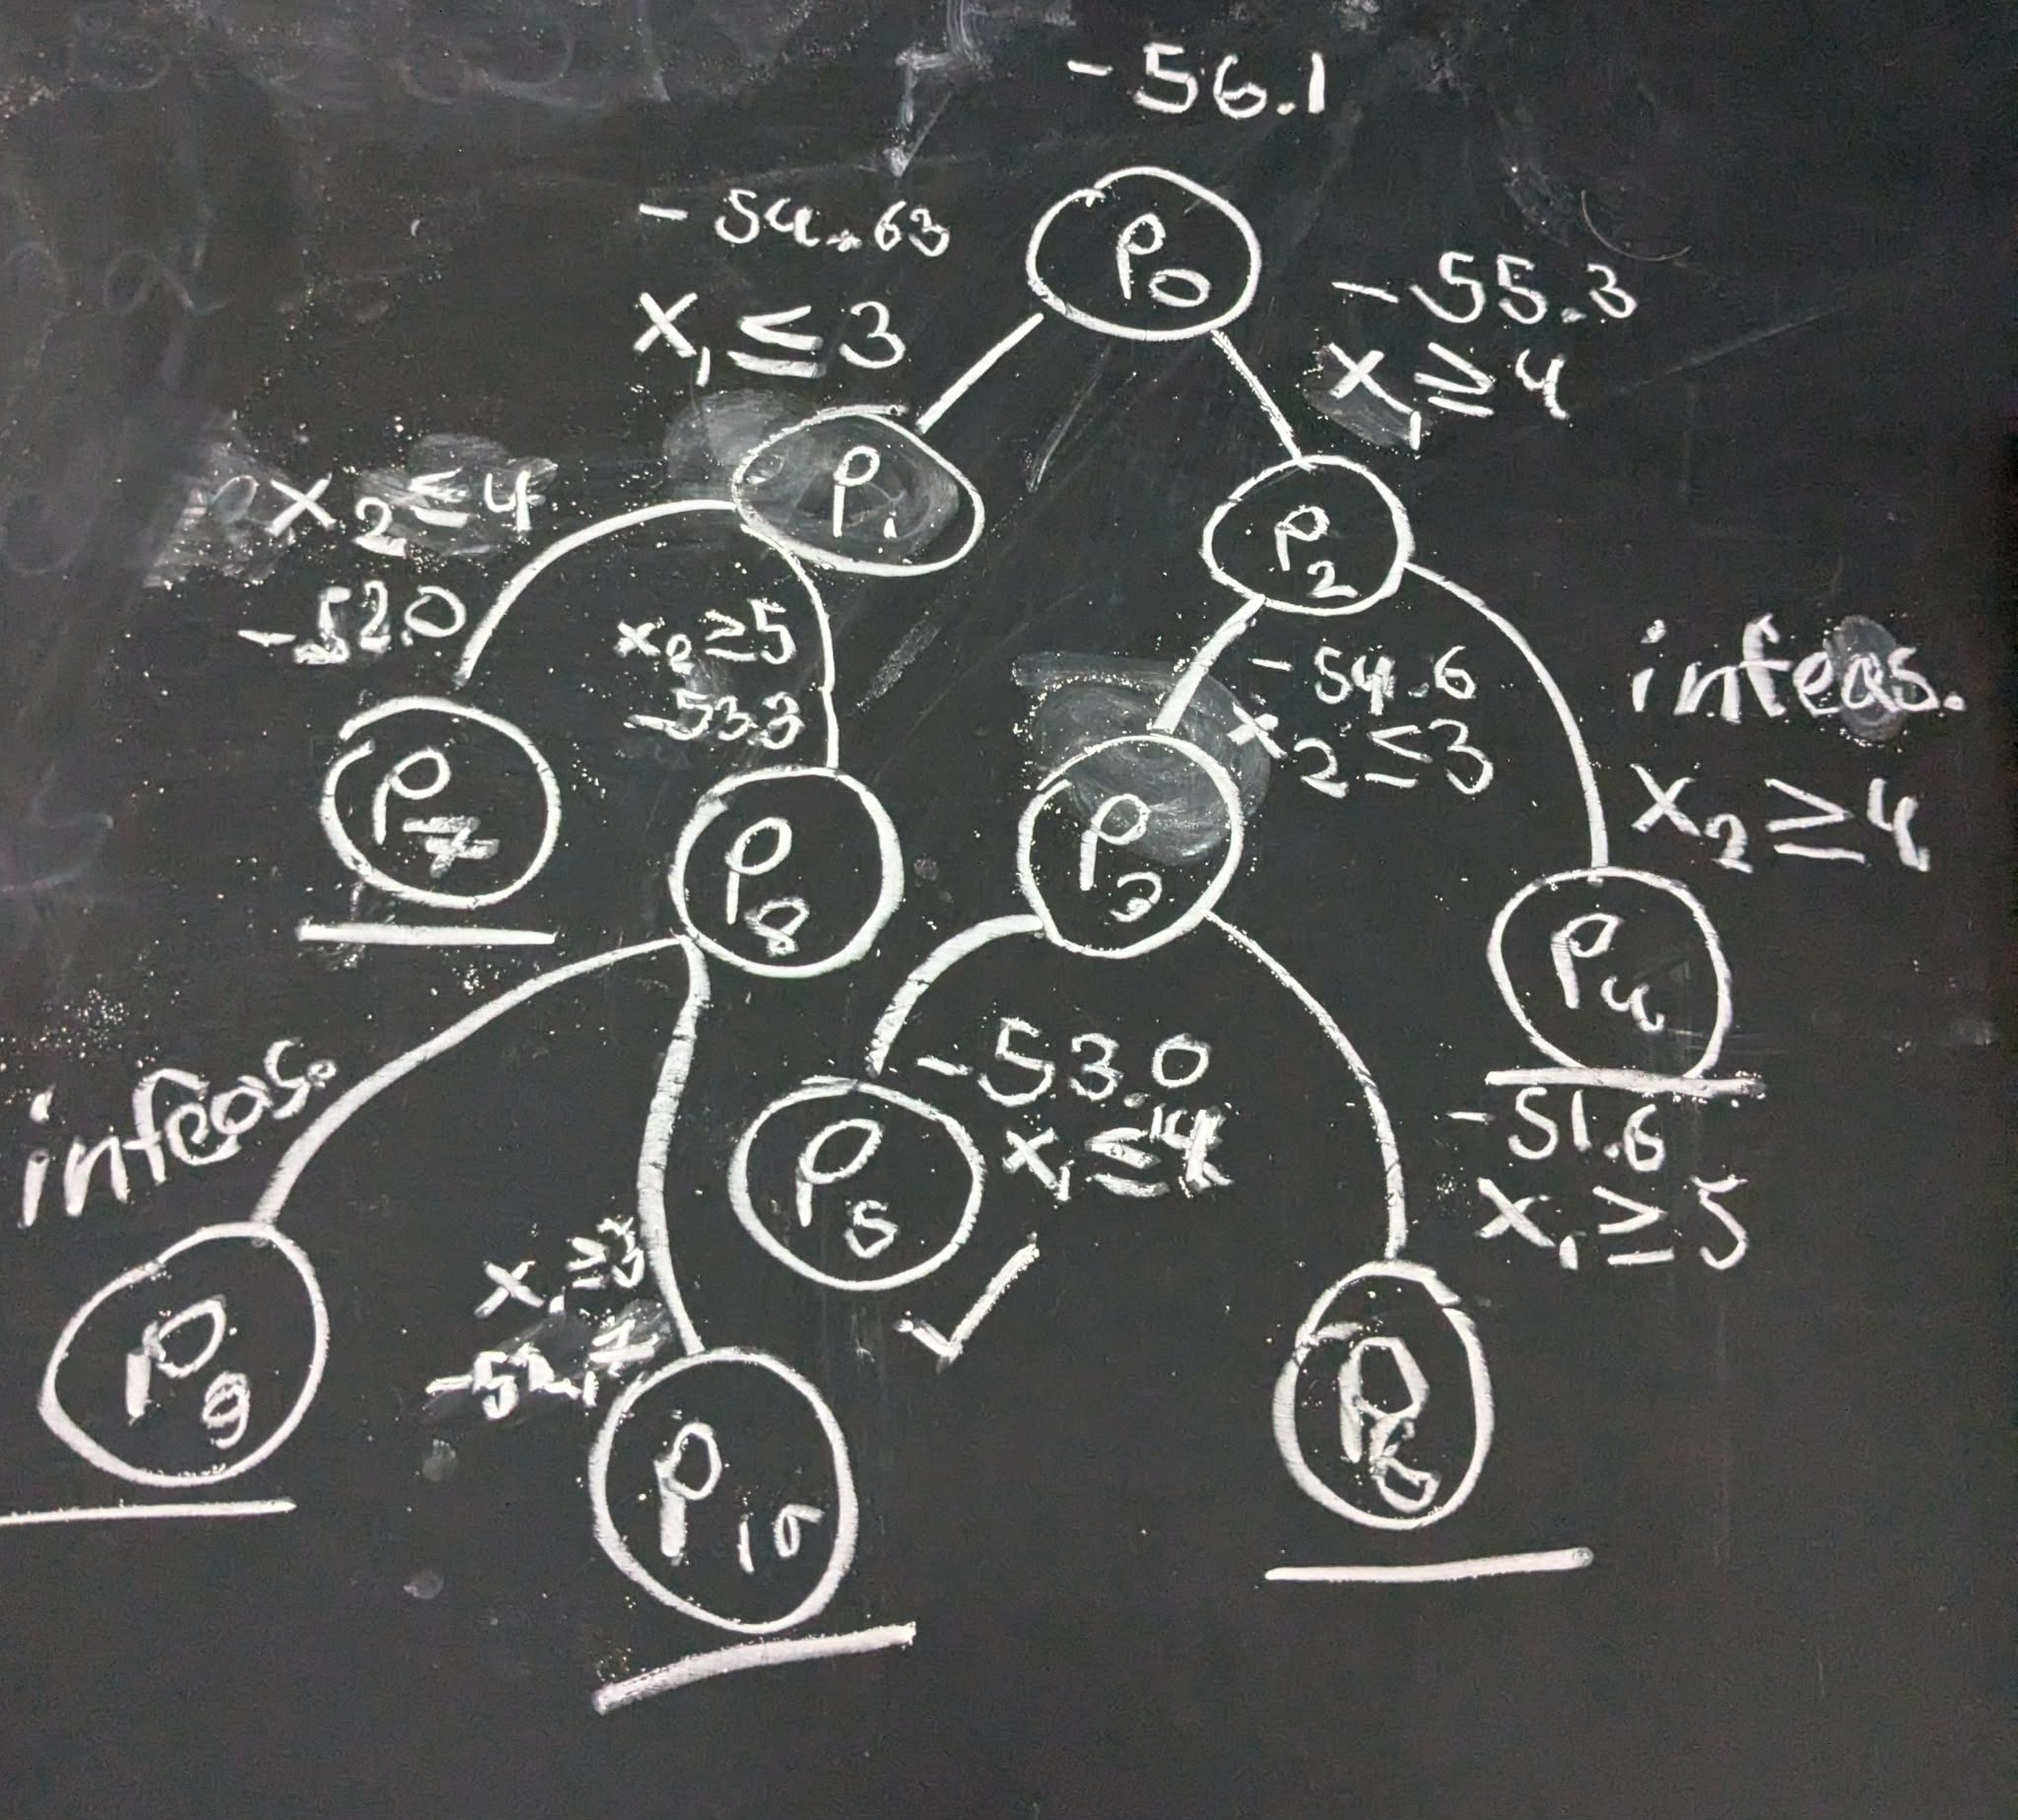

In [16]:
from IPython.display import Image
Image(filename="tree.jpg")

\newpage
# Spm. 3)
Jeg opstiller modellen jf. beskrivelsen fra første delopgave, dog med den
tilføjede begrænsning om heltalskrav. Bemærk, at vi fra figuren i Spm. 1 ved
 at heltalsløsningen er begrænset til
 $$
  x_1 \in \{x \in \mathbb{N}_0\: : \:  x \leq 5 \}, \quad x_2 \in \{x \in
  \mathbb{N}_0\: : \:  x \leq 6 \}
$$

In [15]:
model = PLP.LpProblem(name="ILP2021", sense=PLP.LpMaximize)

x_range = range(2)
x1 = PLP.LpVariable("x1", cat=PLP.LpInteger, lowBound=0, upBound=5)
x2 = PLP.LpVariable("x2", cat=PLP.LpInteger, lowBound=0, upBound=6)

# Objective
model += 8*x1 + 7*x2, "Objective"

# Constraints
n,m = coeffcient_matrix.shape
for i in range(n):
    model += PLP.lpSum(coeffcient_matrix[i,j]*[x1,x2][j]
    for j in range(m)) <= rhs[i]

# Solve model and print the solution.
print_solution(model, condition = lambda x: abs(x.varValue) >= 0.1)


Status: Optimal
x1 = 4.0
x2 = 3.0
Obj. =  53.0


We får den optimale heltalsløsning
$$x_1 = 4, \, x_2 = 3,$$
med objektværdi
$$z = 53.0$$